In [1]:
library(ComplexHeatmap)
library(circlize)
library(dplyr)

Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.17
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [2]:
df_all <- read.csv("data/snRNA_data/DEG/Retinal ganglion cell.csv", stringsAsFactors = FALSE)

In [3]:
fc_mat <- data.frame(a=NULL,b=NULL,c=NULL)
pval_mat <- data.frame(a=NULL,b=NULL,c=NULL)

for(i in c('Piezo1','Cav1','Calm1','Calm2','Camk2d','Ryr1','Ryr2','Yap1','Wwtr1','Tead1','Stk3','Rock1','Rock2','Ddit3','Prkd1')){
    logfc <- c(df_all[df_all$COH_2w_names==i,'COH_2w_logfoldchanges'],df_all[df_all$COH_4w_names==i,'COH_4w_logfoldchanges'],df_all[df_all$COH_8w_names==i,'COH_8w_logfoldchanges'])
    pval <- c(df_all[df_all$COH_2w_names==i,'COH_2w_pvals_adj'],df_all[df_all$COH_4w_names==i,'COH_4w_pvals_adj'],df_all[df_all$COH_8w_names==i,'COH_8w_pvals_adj'])
    fc_mat <- rbind(fc_mat,logfc)
    pval_mat <- rbind(pval_mat,pval)
}

colnames(fc_mat) <- c('COH_2w','COH_4w','COH_8w')
colnames(pval_mat) <- c('COH_2w','COH_4w','COH_8w')
rownames(fc_mat) <- c('Piezo1','Cav1','Calm1','Calm2','Camk2d','Ryr1','Ryr2','Yap1','Wwtr1','Tead1','Stk3','Rock1','Rock2','Ddit3','Prkd1')
rownames(pval_mat) <- c('Piezo1','Cav1','Calm1','Calm2','Camk2d','Ryr1','Ryr2','Yap1','Wwtr1','Tead1','Stk3','Rock1','Rock2','Ddit3','Prkd1')

In [4]:
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("#547297", "#ffffff", "#da5a58"))

In [5]:
sig_func = function(j, i, x, y, width, height, fill) {
    p = pval_mat[i, j]
    if (!is.na(p) && p < 0.001) {
        grid.text("***", x, y, gp = gpar(fontsize = 13, col = "black"))
    } else if (!is.na(p) && p < 0.01) {
        grid.text("**", x, y, gp = gpar(fontsize = 13, col = "black"))
    } else if (!is.na(p) && p < 0.05) {
        grid.text("*", x, y, gp = gpar(fontsize = 13, col = "black"))
    }
}

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


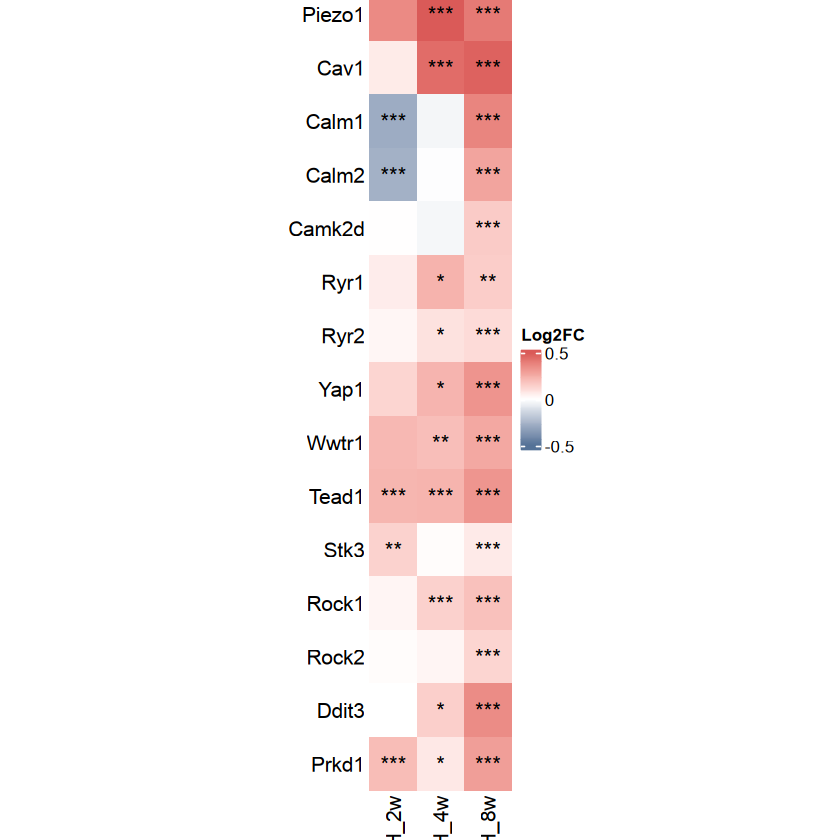

In [6]:
Heatmap(
    fc_mat,
    col = col_fun,
    cell_fun = sig_func,
    row_names_side = "left",
    column_names_side = "bottom",
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    column_title = " ",
    row_title = " ",
    heatmap_legend_param = list(title = "Log2FC"),
    width = unit(3, "cm"),
    height = unit(17, "cm")
    )